In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

# Cấu hình thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# 1. Tải dataset gốc (Kaggle version)
print("--- 1. Loading Dataset ---")
df = pd.read_csv('./dataset/titanic.csv')
print(df.head())


--- 1. Loading Dataset ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450  


--- 2. Visualizing Data ---


/tmp/ipykernel_1523510/3252579962.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[1, 0], palette='viridis')


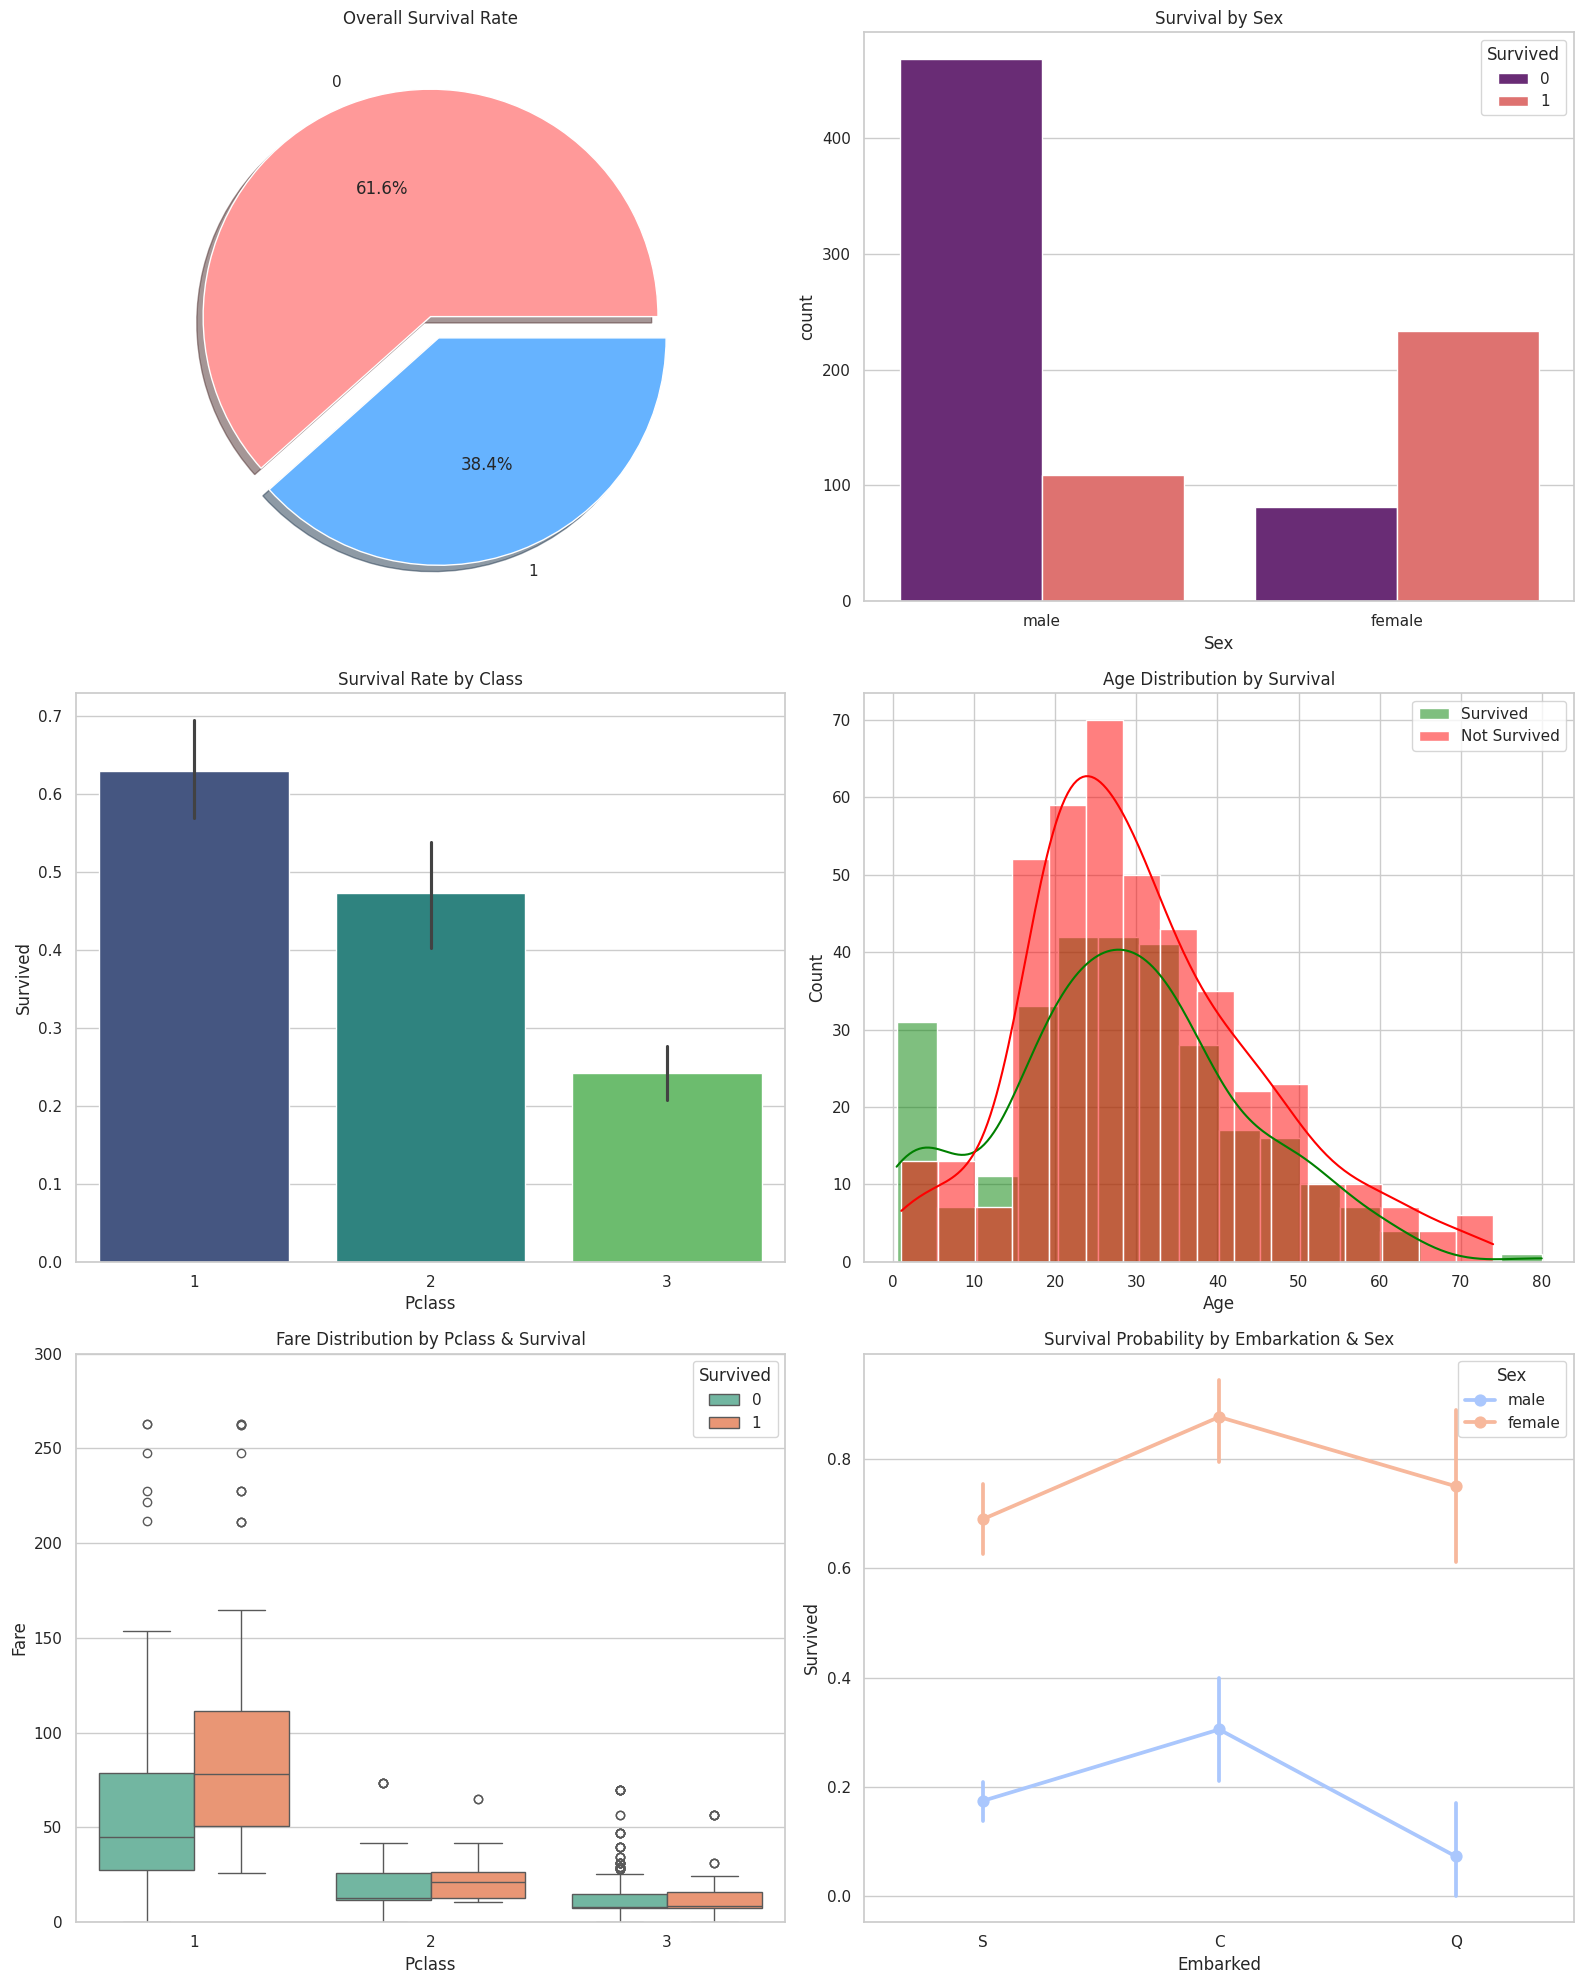

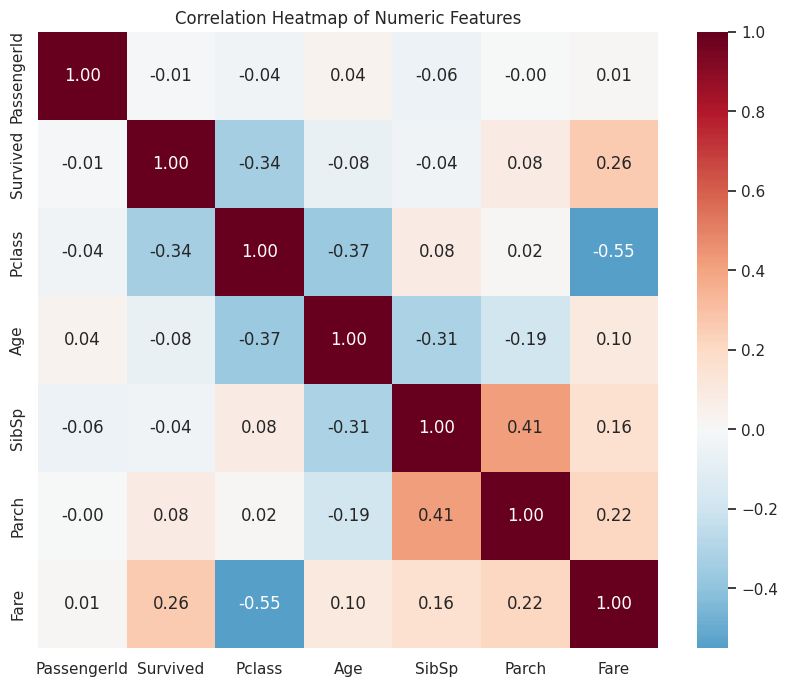

In [2]:
# 2. Phân tích và Trực quan hóa dữ liệu (Exploratory Data Analysis - EDA)
print("\n--- 2. Visualizing Data ---")

# Tạo một lưới biểu đồ 3x2
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# 1. Tỉ lệ sống sót tổng quan (Pie chart)
df['Survived'].value_counts().plot.pie(
    explode=[0, 0.1], autopct='%1.1f%%', ax=axes[0, 0], shadow=True, colors=['#ff9999','#66b3ff']
)
axes[0, 0].set_title('Overall Survival Rate')
axes[0, 0].set_ylabel('')

# 2. Sống sót theo Giới tính (Countplot)
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Survival by Sex')

# 3. Sống sót theo Hạng vé (Pclass)
sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Survival Rate by Class')

# 4. Phân phối Tuổi (Distribution Plot)
sns.histplot(df[df['Survived'] == 1]['Age'].dropna(), color='green', label='Survived', kde=True, ax=axes[1, 1], alpha=0.5)
sns.histplot(df[df['Survived'] == 0]['Age'].dropna(), color='red', label='Not Survived', kde=True, ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_title('Age Distribution by Survival')
axes[1, 1].legend()

# 5. Mối quan hệ giữa Giá vé và Hạng vé (Boxplot)
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Survived', ax=axes[2, 0], palette='Set2')
axes[2, 0].set_title('Fare Distribution by Pclass & Survival')
axes[2, 0].set_ylim(0, 300) # Giới hạn để dễ quan sát

# 6. Sống sót theo Cổng lên tàu (Embarked)
sns.pointplot(data=df, x='Embarked', y='Survived', hue='Sex', ax=axes[2, 1], palette='coolwarm')
axes[2, 1].set_title('Survival Probability by Embarkation & Sex')

plt.tight_layout()
plt.show()

# Biểu đồ Heatmap tương quan giữa các biến số
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()



--- 3. Data Preprocessing ---


/tmp/ipykernel_1523510/757945972.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Title', y='Survived', palette='pastel')


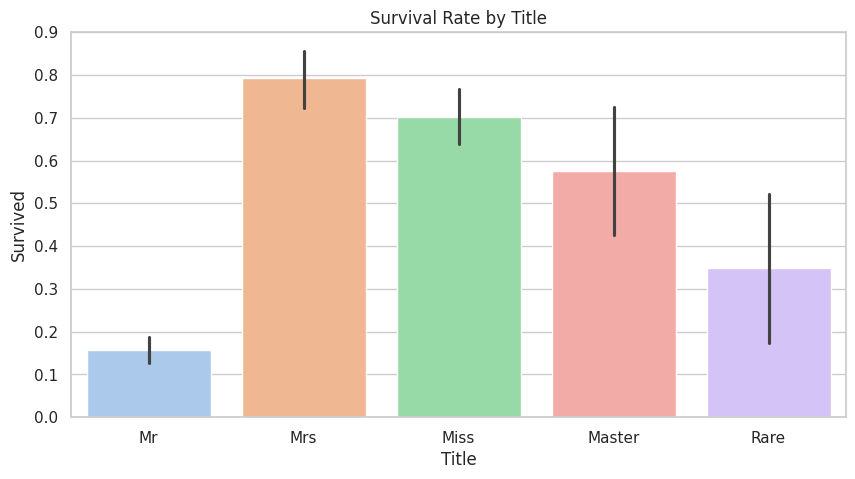


Data after preprocessing:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Title  FamilySize  \
0         0       3    1  22.0      1      0   7.2500      2           2   
1         1       1    0  38.0      1      0  71.2833      3           2   
2         1       3    0  26.0      0      0   7.9250      1           1   
3         1       1    0  35.0      1      0  53.1000      3           2   
4         0       3    1  35.0      0      0   8.0500      2           1   

   IsAlone  Embarked_C  Embarked_Q  Embarked_S  
0        0       False       False        True  
1        0        True       False       False  
2        1       False       False        True  
3        0       False       False        True  
4        1       False       False        True  


In [3]:
# 3. Tiền xử lý dữ liệu (Preprocessing)
print("\n--- 3. Data Preprocessing ---")

# 3.1 Xử lý giá trị khuyết
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# 3.2 Trích xuất Title từ Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 3.3 Kỹ nghệ đặc trưng
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Visualize Title vs Survival
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Title', y='Survived', palette='pastel')
plt.title('Survival Rate by Title')
plt.show()

# 3.4 Loại bỏ các cột thừa
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# 3.5 Mã hóa
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Title'] = le.fit_transform(df['Title'])
df = pd.get_dummies(df, columns=['Embarked'])

print("\nData after preprocessing:")
print(df.head())


In [4]:
# 4. Chia dữ liệu Train/Test
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
# 5. Build & Train Model (Logistic Regression)
print("\n--- 4. Building & Training Model ---")
model = LogisticRegression()
model.fit(X_train_scaled, y_train)



--- 4. Building & Training Model ---


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'



Accuracy Score: 0.8100558659217877

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



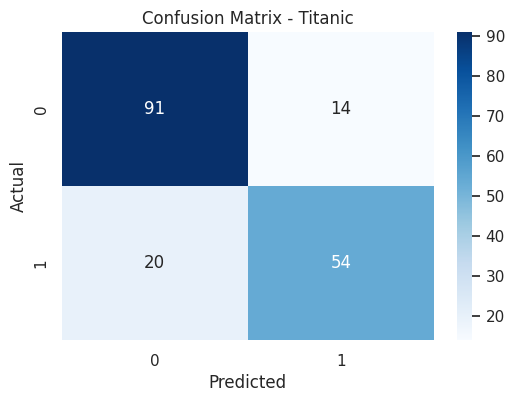

In [6]:
# 6. Đánh giá (Evaluation)
y_pred = model.predict(X_test_scaled)
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Titanic')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
